In [63]:
import sys
from pathlib import Path


PROJECT_ROOT = Path.cwd().parents[0]
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

print("Added to sys.path:", SRC_PATH)

Added to sys.path: /Users/susmitasingh/Documents/GitHub/Portfolio_Risk_Monitor/src


In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from features.returns import compute_log_returns
from risk.var_historical import historical_var
from risk.var_parametric import parametric_var
from features.returns import build_returns_dataframe
from portfolio.portfolio import compute_portfolio_returns
from portfolio.portfolio_stats import portfolio_mean_std
from datalayer.downloader import fetch_prices


In [54]:
df = pd.read_csv("../data/raw/XOM.US.csv", parse_dates=["Date"], index_col="Date")

# Compute log returns
log_returns = compute_log_returns(df)

print(log_returns.head())

Date
1970-01-05    0.021561
1970-01-06   -0.005225
1970-01-07   -0.005330
1970-01-08    0.000000
1970-01-09    0.005330
Name: Close, dtype: float64


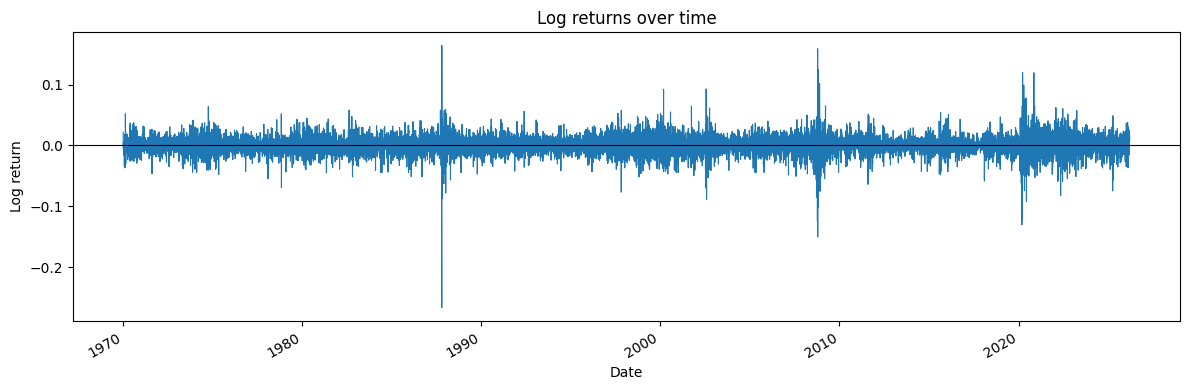

In [55]:
# Time series plot of log returns
ax = log_returns.plot(figsize=(12, 4), linewidth=0.8)
ax.set_title("Log returns over time")
ax.set_xlabel("Date")
ax.set_ylabel("Log return")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


In [5]:
var_95 = historical_var(log_returns, alpha=0.05)


In [6]:
var_95

np.float64(-0.02257443398825951)

In [7]:
# Create synthetic price data (3 assets)
dates = pd.date_range("2026-01-01", periods=6)

df1 = pd.DataFrame({
    "Close": [100, 102, 101, 103, 104, 105]
}, index=dates)

df2 = pd.DataFrame({
    "Close": [200, 198, 202, 204, 203, 205]
}, index=dates)

df3 = pd.DataFrame({
    "Close": [300, 303, 306, 309, 312, 315]
}, index=dates)

price_data = {"A": df1, "B": df2, "C": df3}

weights = [0.5, 0.3, 0.2]

In [8]:
df_returns = build_returns_dataframe(price_data)

In [9]:
df_returns

,A,B,C
2026-01-02,0.019803,-0.010050,0.009950
2026-01-03,-0.009852,0.020001,0.009852
2026-01-04,0.019608,0.009852,0.009756
2026-01-05,0.009662,-0.004914,0.009662
2026-01-06,0.009569,0.009804,0.009569


In [10]:
port_returns = compute_portfolio_returns(df_returns, weights)
port_returns 


2026-01-02    0.008876
2026-01-03    0.003045
2026-01-04    0.014711
2026-01-05    0.005289
2026-01-06    0.009640
Freq: D, dtype: float64

In [11]:
var_hist = historical_var(port_returns, alpha=0.05)

In [12]:
var_hist

np.float64(0.0034934355027753114)

In [13]:
mu, sigma = portfolio_mean_std(df_returns, weights)

In [14]:
var_param = parametric_var(mu, sigma, alpha=0.05)

In [15]:
var_param

np.float64(0.0009600836426703532)

In [16]:
returns = pd.DataFrame({
    "A": np.random.normal(0, 0.02, 10000),
    "B": np.random.normal(0, 0.02, 10000)
})

weights = [0.5, 0.5]

In [17]:
port_returns = compute_portfolio_returns(returns, weights)
mu, sigma = portfolio_mean_std(returns, weights)

var_hist = historical_var(port_returns, alpha=0.05)
var_param = parametric_var(mu, sigma, alpha=0.05)

In [18]:
var_hist, var_param

(np.float64(-0.023531101641586737), np.float64(-0.02372983382550576))

In [19]:
var_hist-var_param

np.float64(0.00019873218391902245)

In [20]:
1e-3

0.001

In [21]:
from scipy.stats import norm

In [22]:
norm.ppf(0.2)

np.float64(-0.8416212335729142)

In [23]:
norm.ppf(0.05)

np.float64(-1.6448536269514729)

In [24]:
csv_path = PROJECT_ROOT / "data" / "raw" / "SPY.US.csv"

In [25]:
with open(csv_path) as f:
    lines = f.readlines()
    counts = [line.count(',') for line in lines]
    print(set(counts))

{5}


In [26]:
ASSETS =  [
    "SPY.US", "QQQ.US", "IWM.US", "XLF.US",
    "XLK.US", "XLE.US", "TLT.US", "LQD.US",
    "GLD.US", "SLV.US", "VNQ.US", "XOM.US"
    ]  

In [27]:
for a in ASSETS:
    csv_path = PROJECT_ROOT / "data" / "raw" / f"{a}.csv"
    with open(csv_path) as f:
        lines = f.readlines()
        counts = [line.count(',') for line in lines]
        print(f"{a}: {set(counts)}")

SPY.US: {5}
QQQ.US: {5}
IWM.US: {5}
XLF.US: {5}
XLK.US: {5}
XLE.US: {5}
TLT.US: {5}
LQD.US: {5}
GLD.US: {5}
SLV.US: {5}
VNQ.US: {5}
XOM.US: {5}


In [28]:
import requests

symbol = "SPY.US"
url = "https://stooq.com/q/d/l/?s=spy.us&i=d"

r = requests.get(url)
print(r.status_code)
print(repr(r.text[:1000]))  # raw chars, shows \n \r etc

200
'Get your apikey:\n\n1. Open https://stooq.com/q/d/?s=spy.us&get_apikey\n2. Enter the captcha code.\n3. Copy the CSV download link at the bottom of the page - it will contain the <apikey> variable.\n4. Append the <apikey> variable with its value to your requests, e.g.\n   https://stooq.com/q/d/l/?s=spy.us&i=d&apikey=XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX\n'


In [29]:
url = f"https://stooq.com/q/d/l/?s={symbol}&i=d"
df = pd.read_csv(url, on_bad_lines='skip')

In [41]:
df

,Get your apikey:
0,1. Open https://stooq.com/q/d/?s=SPY.US&get_ap...
1,2. Enter the captcha code.
2,3. Copy the CSV download link at the bottom of...
3,https://stooq.com/q/d/l/?s=SPY.US&i=d&apike...


In [42]:
import yfinance as yf

def fetch_stooq(symbol):
    # Stooq uses "SPY.US" format, yfinance just needs "SPY"
    ticker = symbol.split(".")[0]
    df = yf.download(ticker, period="5d", auto_adjust=True, progress=False)
    df = df.reset_index()
    df.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']  # match your existing schema
    return df


In [43]:
df_yf = fetch_stooq("QQQ.US")

In [44]:
df_yf

,Date,Open,High,Low,Close,Volume
0,2026-04-08,606.090027,609.900024,602.119995,608.710022,63086000
1,2026-04-09,610.190002,610.500000,603.030029,605.929993,37837500
2,2026-04-10,611.070007,613.669983,609.580017,611.840027,34038500
3,2026-04-13,617.390015,626.739990,608.109985,609.479980,32972100
4,2026-04-14,628.599976,628.599976,620.099976,620.219971,48253723


In [30]:
mu

np.float64(-0.0004286300906943412)

In [56]:
tickers =  [
    "SPY.US", "QQQ.US"
    ]  

In [57]:
weights = [0.7, 0.3]

In [58]:
price_data = {}

# Load price data for each ticker
for ticker in tickers:
    file_path = f"../data/raw/{ticker}.csv"

    df = pd.read_csv(file_path, index_col="Date", parse_dates=True)
    price_data[ticker] = df

# Build returns dataframe
df_returns = build_returns_dataframe(price_data)

# Compute portfolio returns
portfolio_returns = compute_portfolio_returns(df_returns, weights)


In [59]:
mu, sigma = portfolio_mean_std(df_returns, weights)

In [61]:
mu, sigma

(np.float64(0.00042630037534249635), np.float64(0.01227518327612881))

In [62]:
sigma/mu

np.float64(28.79468090138728)

In [50]:
portfolio_returns

Date
2005-02-28   -0.007962
2005-03-01    0.006887
2005-03-02   -0.000437
2005-03-03   -0.002202
2005-03-04    0.010515
                ...   
2026-03-11   -0.000951
2026-03-12   -0.015853
2026-03-13   -0.005704
2026-03-16    0.010381
2026-03-17    0.003593
Length: 5295, dtype: float64

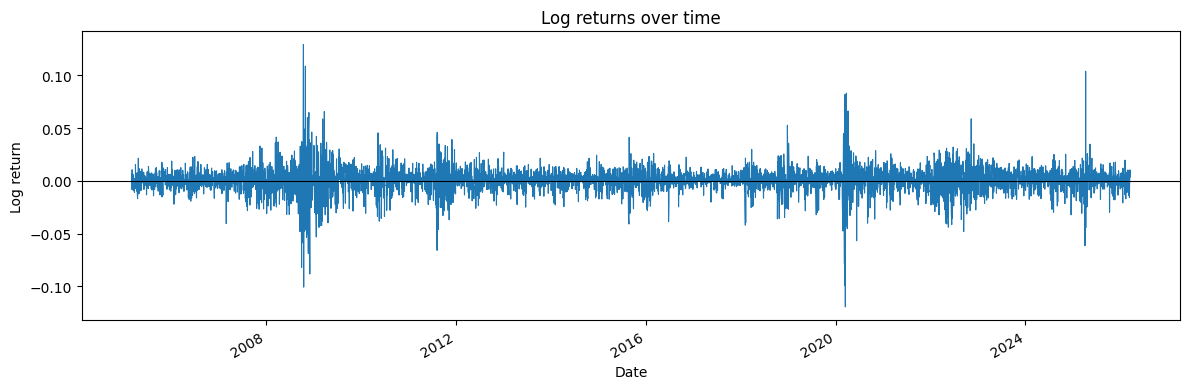

In [51]:
# Time series plot of log returns
ax = portfolio_returns.plot(figsize=(12, 4), linewidth=0.8)
ax.set_title("Log returns over time")
ax.set_xlabel("Date")
ax.set_ylabel("Log return")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


In [69]:
fetch_prices("SPY", period="1mo")

TypeError: fetch_prices() got an unexpected keyword argument 'period'

In [72]:
import yfinance as yf

In [77]:
df=yf.download("SPY", period="10d", auto_adjust=True, progress=False)

In [79]:
df.head(2)

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2026-04-06,658.929993,659.719971,655.520020,655.859985,39105800
2026-04-07,659.219971,659.609985,651.059998,656.650024,69980400


In [82]:
r=compute_log_returns(df)

In [83]:
historical_var(r, alpha=0.05)

np.float64(-0.0002212088321035269)

In [84]:
df = pd.read_csv("../data/raw/SPY.csv", parse_dates=["Date"], index_col="Date")

In [87]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 26 entries, NaT to 2026-04-17
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Close   26 non-null     str  
 1   High    26 non-null     str  
 2   Low     26 non-null     str  
 3   Open    26 non-null     str  
 4   Volume  26 non-null     str  
dtypes: str(5)
memory usage: 1.2 KB


In [89]:
r = compute_log_returns(df)

In [88]:
df["Close"] = pd.to_numeric(df["Close"], errors="coerce")

In [91]:
r.mean()

np.float64(0.0024888909656077883)

In [92]:
df.columns = df.columns.get_level_values(0)

In [94]:
df.columns.get_level_values(0)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

In [96]:
df = df.reset_index()

In [97]:
df

,index,Date,Close,High,Low,Open,Volume
0,0,NaT,NaN,SPY,SPY,SPY,SPY
1,1,2026-03-17,668.963013,672.60309589337,667.8760155087483,670.5586914524959,87128000
2,2,2026-03-18,659.628540,667.8959397089973,659.3892034355257,666.5396583763402,82062600
3,3,2026-03-19,658.002991,661.1743225351036,653.3855958813168,655.1806813207687,111272500
4,4,2026-03-20,648.570007,656.6900024414062,644.719970703125,656.510009765625,163617500
5,5,2026-03-23,655.380005,662.6199951171875,653.9400024414062,658.0700073242188,134802700
6,6,2026-03-24,653.179993,657.030029296875,649.8800048828125,651.3200073242188,96457500
7,7,2026-03-25,656.820007,660.8900146484375,654.239990234375,658.6699829101562,90653800
8,8,2026-03-26,645.090027,654.8499755859375,644.8200073242188,652.0599975585938,96494400
9,9,2026-03-27,634.090027,642.6599731445312,633.1099853515625,642.5,103649400


In [98]:
df.columns = df.columns.get_level_values(0)

In [104]:
df.head()

,index,Date,Close,High,Low,Open,Volume
0,0,NaT,NaN,SPY,SPY,SPY,SPY
1,1,2026-03-17,668.963013,672.60309589337,667.8760155087483,670.5586914524959,87128000
2,2,2026-03-18,659.628540,667.8959397089973,659.3892034355257,666.5396583763402,82062600
3,3,2026-03-19,658.002991,661.1743225351036,653.3855958813168,655.1806813207687,111272500
4,4,2026-03-20,648.570007,656.6900024414062,644.719970703125,656.510009765625,163617500


In [105]:
df = df.dropna(subset=["Date"])

In [106]:
df

,index,Date,Close,High,Low,Open,Volume
1,1,2026-03-17,668.963013,672.60309589337,667.8760155087483,670.5586914524959,87128000
2,2,2026-03-18,659.628540,667.8959397089973,659.3892034355257,666.5396583763402,82062600
3,3,2026-03-19,658.002991,661.1743225351036,653.3855958813168,655.1806813207687,111272500
4,4,2026-03-20,648.570007,656.6900024414062,644.719970703125,656.510009765625,163617500
5,5,2026-03-23,655.380005,662.6199951171875,653.9400024414062,658.0700073242188,134802700
6,6,2026-03-24,653.179993,657.030029296875,649.8800048828125,651.3200073242188,96457500
7,7,2026-03-25,656.820007,660.8900146484375,654.239990234375,658.6699829101562,90653800
8,8,2026-03-26,645.090027,654.8499755859375,644.8200073242188,652.0599975585938,96494400
9,9,2026-03-27,634.090027,642.6599731445312,633.1099853515625,642.5,103649400
10,10,2026-03-30,631.969971,640.3699951171875,629.280029296875,640.1099853515625,99275900
